# GAIN Database Orientation

**Purpose:** Build human confidence in `db/gain.db` before drawing any journalistic conclusions from it. Every number here ties to a query you can re-run. This notebook deliberately avoids identifying "leads" — it only answers the question: *what is in the database, how complete is it, and where should we be cautious?*

**Corpus:** Federal lobbying + congressional press releases, 2022 – 2026 Q1
- Senate LDA filings + LD-203 political contributions (from `data/senate/`)
- House LDA filings (from `data/house/`)
- Congressional member press releases (from `data/congress_press/`)
- Member/bioguide crosswalk (from `unitedstates/congress-legislators`)

**Contents**

1. [Setup & ingest log](#1.-Ingest-Log)
2. [Senate LDA filings](#2.-Senate-LDA-Filings)
3. [Senate political contributions (LD-203)](#3.-Senate-Political-Contributions-(LD-203))
4. [House LDA filings](#4.-House-LDA-Filings)
5. [Congressional press releases](#5.-Congressional-Press-Releases)
6. [Cross-source bridges](#6.-Cross-Source-Bridges)
7. [Data-quality checks](#7.-Data-Quality-Checks)

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from IPython.display import display
warnings.filterwarnings('ignore')

DB_PATH = 'db/gain.db'
conn = sqlite3.connect(DB_PATH)
conn.row_factory = sqlite3.Row

def q(sql, params=()):
    return pd.read_sql_query(sql, conn, params=params)

def pct(part, whole, decimals=1):
    """Format a percentage string, e.g. '64.6%'."""
    return f"{part / whole * 100:.{decimals}f}%"

# consistent plot style
plt.rcParams.update({
    'figure.figsize': (10, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.4,
})

print('Connected to', DB_PATH)

Connected to db/gain.db


---
## 1. Ingest Log

The ingest log is the authoritative record of what was loaded, when, and in how many batches. Every ingester writes here; the row counts below should match the raw source counts verified by the validation scripts.

In [2]:
log = q("""
SELECT source, record_kind,
       sum(n_records)  AS total_records,
       count(*)        AS n_batches,
       max(ingested_at) AS last_ingested
FROM ingest_log
GROUP BY source, record_kind
ORDER BY source, record_kind
""")
display(log)

,source,record_kind,total_records,n_batches,last_ingested
0,house,house_filings,409650,22,2026-06-09T14:15:36+00:00
1,members,committees,230,1,2026-06-09T15:21:41+00:00
2,members,honoree_map,51250,1,2026-06-09T15:21:41+00:00
3,members,legislators,12766,1,2026-06-09T15:21:41+00:00
4,press,press_releases,141332,51,2026-06-09T14:16:01+00:00
5,senate,constants,4,1,2026-06-09T14:12:37+00:00
6,senate,contributions,155682,5,2026-06-09T14:13:19+00:00
7,senate,filings,418098,5,2026-06-09T14:13:19+00:00


**What to check:** `rows` should match `total_records` in the ingest log above. A mismatch means the ingest was partial or a rebuild dropped rows. The `description` column is a one-line summary of what each row represents — for full column-level detail see `docs/*_db.md`.

In [3]:
tables = [
    # Senate lobbying
    ('senate_filings',                        'one filing per registrant → client → period (LD-1/LD-2)'),
    ('senate_lobbying_activities',            'one issue-area + description per filing'),
    ('senate_activity_lobbyists',             'lobbyist × activity, with covered_position (revolving door)'),
    ('senate_activity_government_entities',   'government entity lobbied × activity'),
    ('senate_contribution_filings',           'one LD-203 semi-annual contribution report per filer'),
    ('senate_contribution_items',             'one contribution per honoree per report (honoree_name, amount)'),
    ('senate_contribution_pacs',              'PACs named on LD-203 reports'),
    ('senate_filing_foreign_entities',        'foreign interests disclosed behind a client (LD-1)'),
    ('senate_filing_affiliated_orgs',         'affiliated organisations disclosed on a filing (LD-1)'),
    ('senate_filing_conviction_disclosures',  'lobbyist criminal-conviction disclosures'),
    ('senate_registrants',                    'dim — lobbying firms/orgs, keyed by registrant.id'),
    ('senate_clients',                        'dim — clients on whose behalf lobbying occurs'),
    ('senate_lobbyists',                      'dim — individual lobbyists, keyed by lobbyist.id'),
    # House lobbying
    ('house_filings',                         'one filing per registrant → client → period (LD-1/LD-2)'),
    ('house_activities',                      'one issue-area + description per filing (ali_info)'),
    ('house_filing_lobbyists',                'lobbyists per filing — name-only, no stable ID'),
    ('house_foreign_entities',                'foreign interests on House LD-1 filings'),
    ('house_affiliated_orgs',                 'affiliated organisations on House LD-1 filings'),
    ('house_convictions',                     'lobbyist criminal-conviction disclosures (House)'),
    # Press releases
    ('press_releases',                        'one press release per member page — metadata + full text'),
    ('press_members',                         'one row per member — release counts and date span'),
    # Member crosswalk
    ('members',                               'one row per legislator (current + historical), keyed by bioguide'),
    ('member_terms',                          'every term served — type, state, district, party, dates'),
    ('committees',                            'committees and subcommittees (current congress)'),
    ('member_committees',                     'current committee assignments — side, rank, title'),
    ('honoree_member_map',                    'resolves contribution honoree_name → bioguide, with method + confidence'),
    # Reference vocabularies
    ('ref_issue_codes',                       'controlled vocab — LDA issue-area codes and display names'),
    ('ref_filing_types',                      'controlled vocab — filing type codes and display names'),
    ('ref_government_entities',               'controlled vocab — government entities lobbied (Senate)'),
    ('ref_contribution_item_types',           'controlled vocab — LD-203 contribution item type codes'),
]
rows = [{'table': t, 'description': desc,
         'rows': conn.execute(f'SELECT count(*) FROM {t}').fetchone()[0]}
        for t, desc in tables]
counts = pd.DataFrame(rows)[['table', 'rows', 'description']]
counts['rows'] = counts['rows'].map('{:,}'.format)
with pd.option_context('display.max_colwidth', None):
    display(counts)

,table,rows,description
0,senate_filings,"418,098",one filing per registrant → client → period (LD-1/LD-2)
1,senate_lobbying_activities,"798,998",one issue-area + description per filing
2,senate_activity_lobbyists,"2,121,327","lobbyist × activity, with covered_position (revolving door)"
3,senate_activity_government_entities,"2,015,824",government entity lobbied × activity
4,senate_contribution_filings,"155,682",one LD-203 semi-annual contribution report per filer
5,senate_contribution_items,"636,805","one contribution per honoree per report (honoree_name, amount)"
6,senate_contribution_pacs,"22,377",PACs named on LD-203 reports
7,senate_filing_foreign_entities,"3,627",foreign interests disclosed behind a client (LD-1)
8,senate_filing_affiliated_orgs,"3,663",affiliated organisations disclosed on a filing (LD-1)
9,senate_filing_conviction_disclosures,"1,156",lobbyist criminal-conviction disclosures


---
## 2. Senate LDA Filings

The core lobbying disclosure dataset — one row per registrant→client→period. 418,098 filings from 2022 through early 2026.

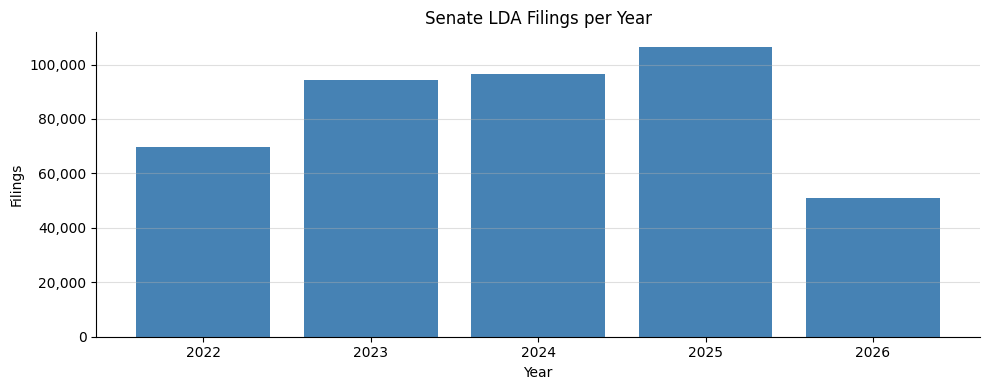

,year,filings,% of total
0,2022,"69,813",16.7%
1,2023,"94,498",22.6%
2,2024,"96,414",23.1%
3,2025,"106,508",25.5%
4,2026,"50,865",12.2%


In [4]:
by_year = q("""
SELECT strftime('%Y', dt_posted) AS year, count(*) AS filings
FROM senate_filings
GROUP BY year ORDER BY year
""")

fig, ax = plt.subplots()
ax.bar(by_year['year'], by_year['filings'], color='steelblue')
ax.set_title('Senate LDA Filings per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Filings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

total = by_year['filings'].sum()
by_year['% of total'] = (by_year['filings'] / total * 100).map('{:.1f}%'.format)
by_year['filings'] = by_year['filings'].map('{:,}'.format)
display(by_year)

In [5]:
ftypes = q("""
SELECT f.filing_type, rt.name AS description, count(*) AS n
FROM senate_filings f
LEFT JOIN ref_filing_types rt ON rt.value = f.filing_type
GROUP BY f.filing_type ORDER BY n DESC
LIMIT 12
""")
total = ftypes['n'].sum()
ftypes['% of shown'] = (ftypes['n'] / total * 100).map('{:.1f}%'.format)
ftypes['n'] = ftypes['n'].map('{:,}'.format)
display(ftypes)

,filing_type,description,n,% of shown
0,Q1,1st Quarter - Report,"93,867",23.8%
1,Q3,3rd Quarter - Report,"76,629",19.4%
2,Q2,2nd Quarter - Report,"76,542",19.4%
3,Q4,4th Quarter - Report,"75,642",19.2%
4,RR,Registration,"20,935",5.3%
5,Q1Y,1st Quarter - Report (No Activity),"11,730",3.0%
6,Q4Y,4th Quarter - Report (No Activity),"10,107",2.6%
7,Q3Y,3rd Quarter - Report (No Activity),"9,868",2.5%
8,Q2Y,2nd Quarter - Report (No Activity),"9,353",2.4%
9,1A,1st Quarter - Amendment,"3,363",0.9%


In [6]:
money = q("""
SELECT
  count(*)                                                                        AS total_filings,
  sum(CASE WHEN income_amt IS NOT NULL AND income_amt > 0 THEN 1 ELSE 0 END)     AS has_income,
  sum(CASE WHEN expenses_amt IS NOT NULL AND expenses_amt > 0 THEN 1 ELSE 0 END) AS has_expenses,
  sum(CASE WHEN income IS NULL AND expenses IS NULL THEN 1 ELSE 0 END)           AS no_money_at_all
FROM senate_filings
""")
t = money['total_filings'][0]
completeness = pd.DataFrame([
    {'field': 'total filings',       'count': t,                              '% of total': '100.0%'},
    {'field': 'has parsed income',   'count': money['has_income'][0],         '% of total': pct(money['has_income'][0], t)},
    {'field': 'has parsed expenses', 'count': money['has_expenses'][0],       '% of total': pct(money['has_expenses'][0], t)},
    {'field': 'no money field at all','count': money['no_money_at_all'][0],   '% of total': pct(money['no_money_at_all'][0], t)},
])
completeness['count'] = completeness['count'].map('{:,}'.format)
display(completeness)
print("NOTE: Many filings are LD-1 registrations (no money) or below the $5k reporting threshold.")

,field,count,% of total
0,total filings,"418,098",100.0%
1,has parsed income,"269,895",64.6%
2,has parsed expenses,"44,302",10.6%
3,no money field at all,"103,901",24.9%


NOTE: Many filings are LD-1 registrations (no money) or below the $5k reporting threshold.


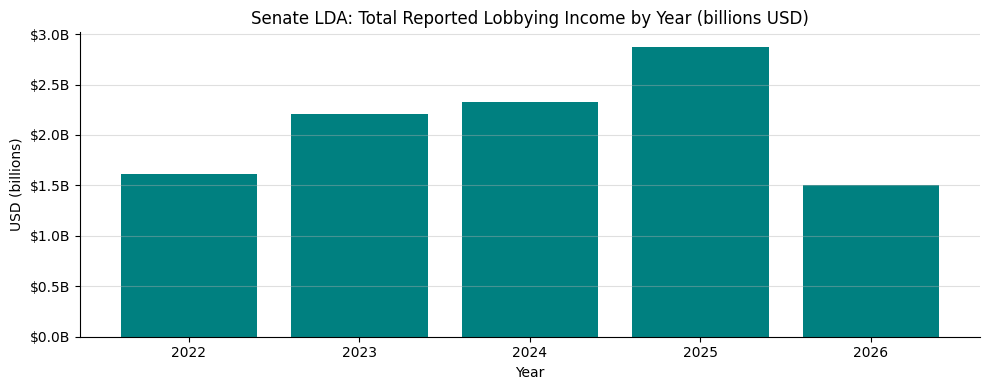

,year,total_income_usd,n_filings_with_income,% of total
0,2022,"$1,610,002,043","44,013",15.3%
1,2023,"$2,212,595,682","60,305",21.0%
2,2024,"$2,325,350,113","62,479",22.1%
3,2025,"$2,873,890,896","68,770",27.3%
4,2026,"$1,502,261,102","34,328",14.3%


In [7]:
income_yr = q("""
SELECT strftime('%Y', dt_posted) AS year,
       sum(income_amt)           AS total_income_usd,
       count(*)                  AS n_filings_with_income
FROM senate_filings
WHERE income_amt IS NOT NULL AND income_amt > 0
GROUP BY year ORDER BY year
""")

fig, ax = plt.subplots()
ax.bar(income_yr['year'], income_yr['total_income_usd'] / 1e9, color='teal')
ax.set_title('Senate LDA: Total Reported Lobbying Income by Year (billions USD)')
ax.set_xlabel('Year')
ax.set_ylabel('USD (billions)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f}B'))
plt.tight_layout()
plt.show()

total_income = income_yr['total_income_usd'].sum()
income_yr['% of total'] = (income_yr['total_income_usd'] / total_income * 100).map('{:.1f}%'.format)
income_yr['total_income_usd'] = income_yr['total_income_usd'].map('${:,.0f}'.format)
income_yr['n_filings_with_income'] = income_yr['n_filings_with_income'].map('{:,}'.format)
display(income_yr)

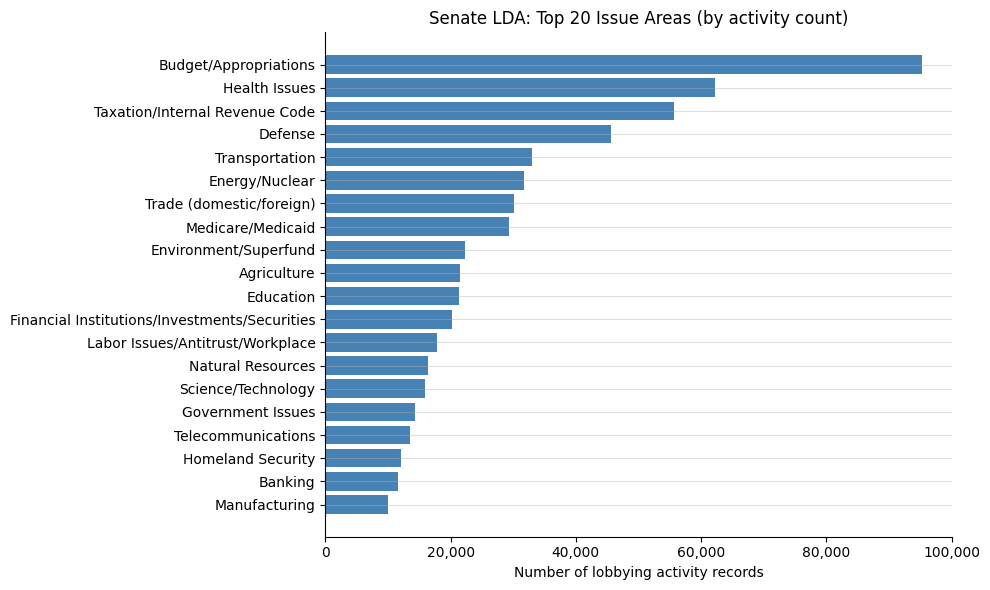

In [8]:
# Top issue codes
issues = q("""
SELECT general_issue_code_display AS issue, count(*) AS activities
FROM senate_lobbying_activities
WHERE general_issue_code_display IS NOT NULL
GROUP BY general_issue_code_display
ORDER BY activities DESC
LIMIT 20
""")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(issues['issue'][::-1], issues['activities'][::-1], color='steelblue')
ax.set_title('Senate LDA: Top 20 Issue Areas (by activity count)')
ax.set_xlabel('Number of lobbying activity records')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [9]:
top_reg = q("""
SELECT r.name AS registrant, count(DISTINCT f.filing_uuid) AS n_filings
FROM senate_filings f
JOIN senate_registrants r ON r.id = f.registrant_id
GROUP BY r.id ORDER BY n_filings DESC
LIMIT 15
""")
total_filings = conn.execute('SELECT count(*) FROM senate_filings').fetchone()[0]
top_reg['% of all filings'] = (top_reg['n_filings'] / total_filings * 100).map('{:.1f}%'.format)
top_reg['n_filings'] = top_reg['n_filings'].map('{:,}'.format)
display(top_reg)

,registrant,n_filings,% of all filings
0,"BROWNSTEIN HYATT FARBER SCHRECK, LLP","5,636",1.3%
1,"CORNERSTONE GOVERNMENT AFFAIRS, INC.","5,554",1.3%
2,HOLLAND & KNIGHT LLP,"5,462",1.3%
3,AKIN GUMP STRAUSS HAUER & FELD,"5,110",1.2%
4,BGR GOVERNMENT AFFAIRS,"4,288",1.0%
5,THORN RUN PARTNERS,"3,894",0.9%
6,"BALLARD PARTNERS, LLC","3,260",0.8%
7,SQUIRE PATTON BOGGS,"3,243",0.8%
8,INVARIANT LLC,"3,210",0.8%
9,"K&L GATES, LLP","3,135",0.7%


In [10]:
dim = q("""
SELECT
  count(*)                                                               AS total_filings,
  sum(CASE WHEN registrant_id IS NOT NULL THEN 1 ELSE 0 END)            AS has_registrant_id,
  sum(CASE WHEN client_id IS NOT NULL THEN 1 ELSE 0 END)                AS has_client_id,
  (SELECT count(*) FROM senate_lobbying_activities)                     AS total_activities,
  (SELECT count(*) FROM senate_activity_lobbyists)                      AS total_lobbyist_rows,
  (SELECT count(*) FROM senate_activity_lobbyists WHERE covered_position IS NOT NULL
     AND covered_position NOT IN ('N/A','See prior filing','Legislative Consultant','Partner'))
                                                                         AS revolving_door_rows
FROM senate_filings
""")
t = dim['total_filings'][0]
t_lob = dim['total_lobbyist_rows'][0]
summary = pd.DataFrame([
    {'metric': 'total filings',                'count': t,                               'denominator': 'filings',          '% of denominator': '100.0%'},
    {'metric': 'has registrant_id',            'count': dim['has_registrant_id'][0],     'denominator': 'filings',          '% of denominator': pct(dim['has_registrant_id'][0], t)},
    {'metric': 'has client_id',                'count': dim['has_client_id'][0],         'denominator': 'filings',          '% of denominator': pct(dim['has_client_id'][0], t)},
    {'metric': 'total activities',             'count': dim['total_activities'][0],      'denominator': 'filings',          '% of denominator': f"{dim['total_activities'][0]/t:.2f}× avg per filing"},
    {'metric': 'revolving-door lobbyist rows', 'count': dim['revolving_door_rows'][0],   'denominator': 'activity_lobbyist rows', '% of denominator': pct(dim['revolving_door_rows'][0], t_lob)},
])
summary['count'] = summary['count'].map('{:,}'.format)
display(summary)

,metric,count,denominator,% of denominator
0,total filings,"418,098",filings,100.0%
1,has registrant_id,"418,098",filings,100.0%
2,has client_id,"418,098",filings,100.0%
3,total activities,"798,998",filings,1.91× avg per filing
4,revolving-door lobbyist rows,"566,714",activity_lobbyist rows,26.7%


In [11]:
# Senate filings without any activities
no_act = conn.execute("""
SELECT count(*) FROM senate_filings f
WHERE NOT EXISTS (
    SELECT 1 FROM senate_lobbying_activities a WHERE a.filing_uuid = f.filing_uuid
)
""").fetchone()[0]
total = conn.execute('SELECT count(*) FROM senate_filings').fetchone()[0]
print(f"Filings with no associated activities: {no_act:,} / {total:,} ({no_act/total*100:.1f}%)")
print("These are typically LD-1 registrations or no-activity quarterly reports.")

Filings with no associated activities: 50,436 / 418,098 (12.1%)
These are typically LD-1 registrations or no-activity quarterly reports.


In [12]:
foreign = q("""
SELECT UPPER(country) AS country, count(*) AS n
FROM senate_filing_foreign_entities
WHERE country IS NOT NULL AND country != ''
GROUP BY UPPER(country)
ORDER BY n DESC
LIMIT 15
""")
total_foreign = foreign['n'].sum()
foreign['% of shown'] = (foreign['n'] / total_foreign * 100).map('{:.1f}%'.format)
foreign['n'] = foreign['n'].map('{:,}'.format)
print('Top 15 countries in Senate foreign entity disclosures (ISO-2 codes):')
display(foreign)

Top 15 countries in Senate foreign entity disclosures (ISO-2 codes):


,country,n,% of shown
0,GB,424,16.3%
1,CA,283,10.9%
2,NL,209,8.0%
3,KR,205,7.9%
4,CN,194,7.5%
5,CH,180,6.9%
6,DE,175,6.7%
7,JP,168,6.5%
8,VG,131,5.0%
9,FR,118,4.5%


---
## 3. Senate Political Contributions (LD-203)

LD-203 semi-annual reports from registrants and lobbyists disclosing contributions to federal candidates, PACs, and parties. 155,682 filings containing 636,805 individual contribution items.

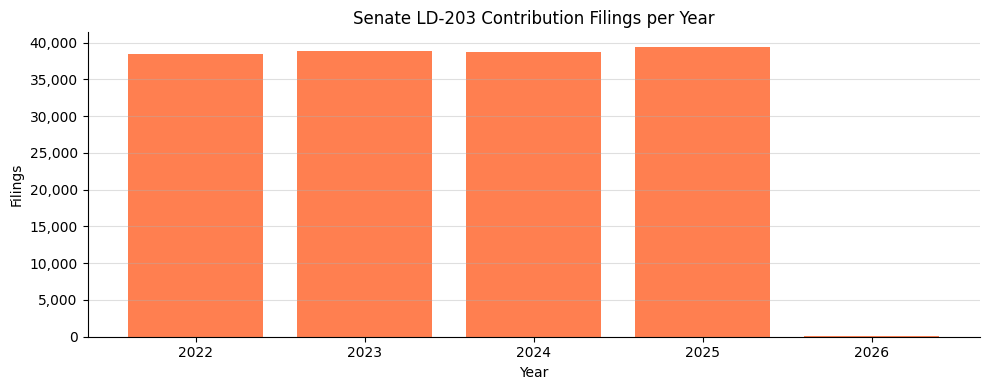

,year,filings,% of total
0,2022,"38,466",24.7%
1,2023,"38,859",25.0%
2,2024,"38,779",24.9%
3,2025,"39,438",25.3%
4,2026,140,0.1%


In [13]:
contrib_yr = q("""
SELECT filing_year AS year, count(*) AS filings
FROM senate_contribution_filings
GROUP BY filing_year ORDER BY filing_year
""")

fig, ax = plt.subplots()
ax.bar(contrib_yr['year'].astype(str), contrib_yr['filings'], color='coral')
ax.set_title('Senate LD-203 Contribution Filings per Year')
ax.set_xlabel('Year')
ax.set_ylabel('Filings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

total = contrib_yr['filings'].sum()
contrib_yr['% of total'] = (contrib_yr['filings'] / total * 100).map('{:.1f}%'.format)
contrib_yr['filings'] = contrib_yr['filings'].map('{:,}'.format)
display(contrib_yr)

In [14]:
ci_stats = q("""
SELECT
  count(*)                                                     AS total_items,
  sum(CASE WHEN amount_num IS NULL THEN 1 ELSE 0 END)          AS null_amount,
  min(amount_num)                                              AS min_amount,
  max(amount_num)                                              AS max_amount,
  round(avg(amount_num), 2)                                    AS avg_amount,
  sum(amount_num)                                              AS total_amount
FROM senate_contribution_items
""")
stats = pd.DataFrame([
    {'statistic': 'total items',    'value': f"{ci_stats['total_items'][0]:,}"},
    {'statistic': 'null amount',    'value': f"{ci_stats['null_amount'][0]:,}  ({pct(ci_stats['null_amount'][0], ci_stats['total_items'][0])})"},
    {'statistic': 'min amount',     'value': f"${ci_stats['min_amount'][0]:,.2f}"},
    {'statistic': 'max amount',     'value': f"${ci_stats['max_amount'][0]:,.2f}"},
    {'statistic': 'avg amount',     'value': f"${ci_stats['avg_amount'][0]:,.2f}"},
    {'statistic': 'total amount',   'value': f"${ci_stats['total_amount'][0]:,.0f}"},
])
display(stats)
print("NOTE: Negative amounts exist — these are refunds or data-entry artifacts. Verify before aggregating.")

,statistic,value
0,total items,"636,805"
1,null amount,0 (0.0%)
2,min amount,"$-250,000.00"
3,max amount,"$5,000,000.00"
4,avg amount,"$2,685.31"
5,total amount,"$1,710,020,714"


NOTE: Negative amounts exist — these are refunds or data-entry artifacts. Verify before aggregating.


In [15]:
honoree_q = q("""
SELECT
  count(*)                                                          AS total_items,
  sum(CASE WHEN honoree_name IS NULL THEN 1 ELSE 0 END)            AS null_honoree,
  sum(CASE WHEN honoree_name = 'N/A' THEN 1 ELSE 0 END)            AS na_honoree,
  count(DISTINCT honoree_name)                                      AS distinct_honorees,
  sum(CASE WHEN honoree_name = 'N/A' THEN amount_num ELSE 0 END)   AS na_amount_usd
FROM senate_contribution_items
""")
t = honoree_q['total_items'][0]
hq = pd.DataFrame([
    {'field': 'total items',         'count': f"{t:,}",                                             '% of total': '100.0%'},
    {'field': 'null honoree_name',   'count': f"{honoree_q['null_honoree'][0]:,}",                  '% of total': pct(honoree_q['null_honoree'][0], t)},
    {'field': "honoree_name = 'N/A'",'count': f"{honoree_q['na_honoree'][0]:,}",                    '% of total': pct(honoree_q['na_honoree'][0], t)},
    {'field': '  → $ behind N/A',    'count': f"${honoree_q['na_amount_usd'][0]:,.0f}",             '% of total': ''},
    {'field': 'distinct honoree names','count': f"{honoree_q['distinct_honorees'][0]:,}",           '% of total': ''},
])
display(hq)
print("NOTE: 'N/A' = unattributed money (~$22M). honoree_name has no standard format;")
print("use honoree_member_map (confidence >= 0.9) for member attribution.")

,field,count,% of total
0,total items,"636,805",100.0%
1,null honoree_name,0,0.0%
2,honoree_name = 'N/A',"5,475",0.9%
3,→ $ behind N/A,"$22,073,597",
4,distinct honoree names,"51,250",


NOTE: 'N/A' = unattributed money (~$22M). honoree_name has no standard format;
use honoree_member_map (confidence >= 0.9) for member attribution.


In [16]:
top_honorees = q("""
SELECT honoree_name, sum(amount_num) AS total_usd, count(*) AS n_items
FROM senate_contribution_items
WHERE honoree_name IS NOT NULL
GROUP BY honoree_name
ORDER BY total_usd DESC
LIMIT 20
""")
grand_total = top_honorees['total_usd'].sum()
top_honorees['% of shown $'] = (top_honorees['total_usd'] / grand_total * 100).map('{:.1f}%'.format)
top_honorees['total_usd'] = top_honorees['total_usd'].map('${:,.0f}'.format)
top_honorees['n_items'] = top_honorees['n_items'].map('{:,}'.format)
print('Top 20 honorees by total contributions (includes PACs and party committees):')
display(top_honorees)
print("NOTE: NRSC, DSCC, NRCC, DCCC are party committees, not individual members.")
print("Use honoree_member_map crosswalk to filter to individual members.")

Top 20 honorees by total contributions (includes PACs and party committees):


,honoree_name,total_usd,n_items,% of shown $
0,N/A,"$22,073,597","5,475",13.1%
1,NRSC,"$12,316,596","2,111",7.3%
2,DSCC,"$11,508,169","1,695",6.8%
3,Senate Majority PAC,"$9,897,923",44,5.9%
4,NRCC,"$9,892,357","1,597",5.9%
5,DCCC,"$9,709,714","1,337",5.8%
6,House Majority PAC,"$9,707,950",50,5.8%
7,None,"$9,375,283","1,074",5.6%
8,Democratic Senatorial Campaign Committee,"$8,717,010","1,021",5.2%
9,National Republican Senatorial Committee,"$8,580,279","1,656",5.1%


NOTE: NRSC, DSCC, NRCC, DCCC are party committees, not individual members.
Use honoree_member_map crosswalk to filter to individual members.


---
## 4. House LDA Filings

The same LD-1/LD-2 disclosure regime filed separately with the House Clerk, parsed from ~409k XML files. Kept in its own `house_*` namespace so House-vs-Senate discrepancies remain visible.

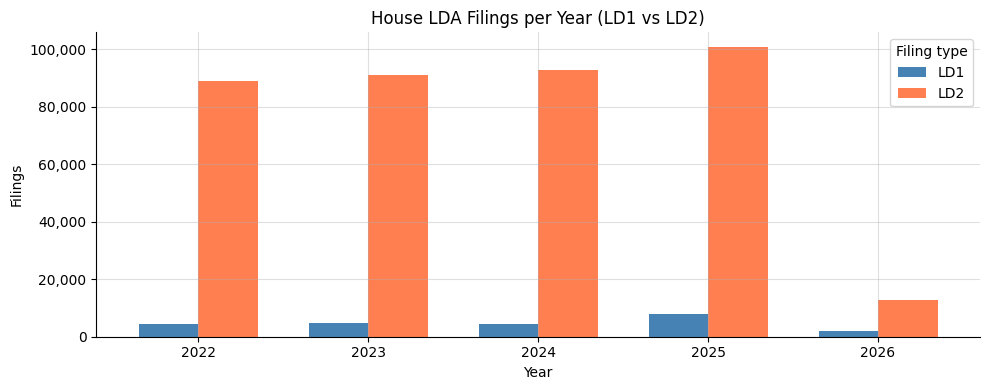

doc_type   LD1     LD2
year                  
2022      4565   88965
2023      4929   90841
2024      4548   92707
2025      7762  100760
2026      1917   12656


In [17]:
# House filings by year and doc_type
house_yr = q("""
SELECT filing_year AS year, doc_type, count(*) AS filings
FROM house_filings
GROUP BY filing_year, doc_type
ORDER BY filing_year, doc_type
""")

house_pivot = house_yr.pivot(index='year', columns='doc_type', values='filings').fillna(0)

fig, ax = plt.subplots()
house_pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], width=0.7)
ax.set_title('House LDA Filings per Year (LD1 vs LD2)')
ax.set_xlabel('Year')
ax.set_ylabel('Filings')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Filing type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(house_pivot.to_string())

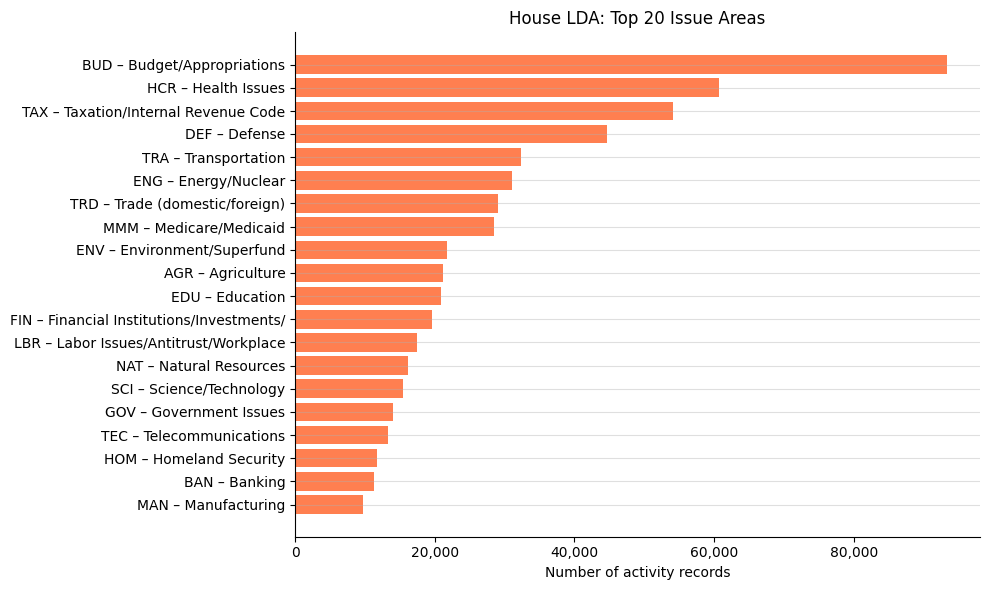

In [18]:
# House: top issue areas (ali codes)
house_issues = q("""
SELECT ha.issue_area_code AS code,
       ri.name            AS description,
       count(*)           AS activities
FROM house_activities ha
LEFT JOIN ref_issue_codes ri ON ri.value = ha.issue_area_code
WHERE ha.issue_area_code IS NOT NULL AND ha.issue_area_code != ''
GROUP BY ha.issue_area_code
ORDER BY activities DESC
LIMIT 20
""")

fig, ax = plt.subplots(figsize=(10, 6))
labels = [
    f"{row['code']} – {row['description'][:35]}" if pd.notna(row['description'])
    else row['code']
    for _, row in house_issues.iterrows()
]
ax.barh(labels[::-1], house_issues['activities'][::-1], color='coral')
ax.set_title('House LDA: Top 20 Issue Areas')
ax.set_xlabel('Number of activity records')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [19]:
house_nulls = q("""
SELECT
  count(*)                                                                  AS total,
  sum(CASE WHEN senate_registrant_id IS NULL THEN 1 ELSE 0 END)            AS no_senate_reg_id,
  sum(CASE WHEN income IS NULL OR income = '' THEN 1 ELSE 0 END)           AS no_income,
  sum(CASE WHEN expenses IS NULL OR expenses = '' THEN 1 ELSE 0 END)       AS no_expenses,
  sum(CASE WHEN doc_type = 'LD1' THEN 1 ELSE 0 END)                        AS ld1_registrations,
  sum(CASE WHEN doc_type = 'LD2' THEN 1 ELSE 0 END)                        AS ld2_quarterly
FROM house_filings
""")
t = house_nulls['total'][0]
hn = pd.DataFrame([
    {'metric': 'total filings',               'count': f"{t:,}",                                        '% of total': '100.0%'},
    {'metric': '  LD1 registrations',         'count': f"{house_nulls['ld1_registrations'][0]:,}",      '% of total': pct(house_nulls['ld1_registrations'][0], t)},
    {'metric': '  LD2 quarterly reports',     'count': f"{house_nulls['ld2_quarterly'][0]:,}",          '% of total': pct(house_nulls['ld2_quarterly'][0], t)},
    {'metric': 'missing senate_registrant_id','count': f"{house_nulls['no_senate_reg_id'][0]:,}",       '% of total': pct(house_nulls['no_senate_reg_id'][0], t, 2)},
    {'metric': 'no income reported',          'count': f"{house_nulls['no_income'][0]:,}",              '% of total': pct(house_nulls['no_income'][0], t)},
    {'metric': 'no expenses reported',        'count': f"{house_nulls['no_expenses'][0]:,}",            '% of total': pct(house_nulls['no_expenses'][0], t)},
])
display(hn)

,metric,count,% of total
0,total filings,"409,650",100.0%
1,LD1 registrations,"23,721",5.8%
2,LD2 quarterly reports,"385,929",94.2%
3,missing senate_registrant_id,0,0.00%
4,no income reported,"146,328",35.7%
5,no expenses reported,"366,611",89.5%


In [20]:
hc  = conn.execute('SELECT count(*) FROM house_convictions').fetchone()[0]
hfe = conn.execute('SELECT count(*) FROM house_foreign_entities').fetchone()[0]
hao = conn.execute('SELECT count(*) FROM house_affiliated_orgs').fetchone()[0]
totld1 = conn.execute("SELECT count(*) FROM house_filings WHERE doc_type='LD1'").fetchone()[0]
ld1_with_foreign = conn.execute(
    "SELECT count(DISTINCT house_filing_id) FROM house_foreign_entities"
).fetchone()[0]
misc = pd.DataFrame([
    {'table': 'house_convictions',     'rows': f'{hc:,}',
     'note': 'lobbyist criminal-conviction disclosures'},
    {'table': 'house_foreign_entities','rows': f'{hfe:,}',
     'note': f'foreign interest rows across {ld1_with_foreign:,} LD1 filings ({pct(ld1_with_foreign, totld1)} of LD1s have ≥1)'},
    {'table': 'house_affiliated_orgs', 'rows': f'{hao:,}',
     'note': 'affiliated organisation rows on LD1 filings'},
])
display(misc)

,table,rows,note
0,house_convictions,"1,160",lobbyist criminal-conviction disclosures
1,house_foreign_entities,"47,983","foreign interest rows across 23,721 LD1 filing..."
2,house_affiliated_orgs,"71,468",affiliated organisation rows on LD1 filings


---
## 5. Congressional Press Releases

Member press releases scraped from `*.house.gov` and `*.senate.gov` sites. 141,332 releases from 536 distinct members, 2022 – 2026 Q1.

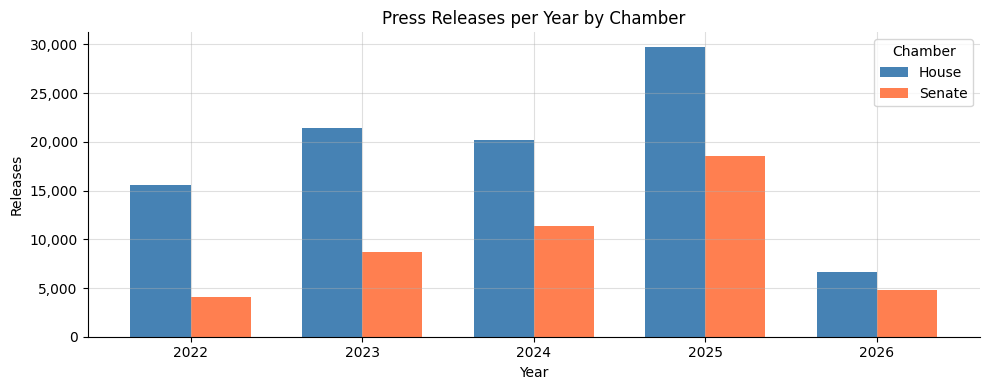

chamber,House,Senate,total,% House,% Senate
year,,,,,
2022,"15,596","4,106","19,702",79%,21%
2023,"21,443","8,734","30,177",71%,29%
2024,"20,215","11,350","31,565",64%,36%
2025,"29,759","18,558","48,317",62%,38%
2026,"6,614","4,821","11,435",58%,42%


In [21]:
press_yr = q("""
SELECT year, chamber, count(*) AS releases
FROM press_releases
WHERE year IS NOT NULL AND chamber IS NOT NULL
GROUP BY year, chamber
ORDER BY year, chamber
""")

press_pivot = press_yr.pivot(index='year', columns='chamber', values='releases').fillna(0)

fig, ax = plt.subplots()
press_pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], width=0.7)
ax.set_title('Press Releases per Year by Chamber')
ax.set_xlabel('Year')
ax.set_ylabel('Releases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(title='Chamber')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

row_totals = press_pivot.sum(axis=1)
dp = press_pivot.copy().astype(int)
dp['total'] = row_totals.astype(int)
dp['% House']  = (press_pivot.get('House',  pd.Series(0, index=press_pivot.index)) / row_totals * 100).map('{:.0f}%'.format)
dp['% Senate'] = (press_pivot.get('Senate', pd.Series(0, index=press_pivot.index)) / row_totals * 100).map('{:.0f}%'.format)
for col in ['House', 'Senate', 'total']:
    if col in dp.columns:
        dp[col] = dp[col].map('{:,}'.format)
display(dp)

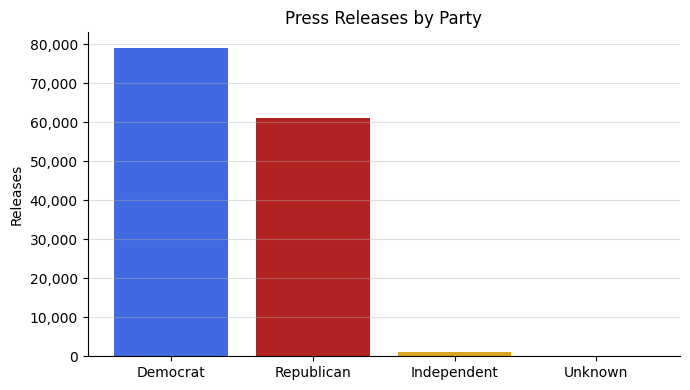

,party,releases,% of total
0,Democrat,"79,065",55.9%
1,Republican,"61,152",43.3%
2,Independent,993,0.7%
3,NaN,122,0.1%


In [22]:
party = q("""
SELECT party, count(*) AS releases
FROM press_releases
GROUP BY party ORDER BY releases DESC
""")

colors_map = {'Democrat': 'royalblue', 'Republican': 'firebrick', 'Independent': 'goldenrod'}
bar_colors = [colors_map.get(p, 'grey') for p in party['party']]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(party['party'].fillna('Unknown'), party['releases'], color=bar_colors)
ax.set_title('Press Releases by Party')
ax.set_ylabel('Releases')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

total = party['releases'].sum()
party['% of total'] = (party['releases'] / total * 100).map('{:.1f}%'.format)
party['releases'] = party['releases'].map('{:,}'.format)
display(party)

In [23]:
text_q = q("""
SELECT
  count(*)                                                                AS total,
  sum(CASE WHEN bioguide_id IS NULL THEN 1 ELSE 0 END)                   AS no_bioguide,
  sum(CASE WHEN date IS NULL THEN 1 ELSE 0 END)                          AS no_date,
  sum(CASE WHEN text IS NULL OR text = '' THEN 1 ELSE 0 END)             AS no_text,
  count(DISTINCT bioguide_id)                                             AS distinct_members,
  round(avg(length(text)), 0)                                             AS avg_text_chars,
  min(length(text))                                                       AS min_text_chars,
  max(length(text))                                                       AS max_text_chars
FROM press_releases
""")
t = text_q['total'][0]
pr = pd.DataFrame([
    {'field': 'total releases',        'count': f"{t:,}",                                '% of total': '100.0%'},
    {'field': 'missing bioguide_id',   'count': f"{text_q['no_bioguide'][0]:,}",          '% of total': pct(text_q['no_bioguide'][0], t, 2)},
    {'field': 'missing date',          'count': f"{text_q['no_date'][0]:,}",              '% of total': pct(text_q['no_date'][0], t, 2)},
    {'field': 'empty text field',      'count': f"{text_q['no_text'][0]:,}",              '% of total': pct(text_q['no_text'][0], t, 2)},
    {'field': 'distinct members',      'count': f"{text_q['distinct_members'][0]:,}",     '% of total': ''},
    {'field': 'avg text length (chars)','count': f"{text_q['avg_text_chars'][0]:,.0f}",   '% of total': ''},
    {'field': 'min / max text (chars)', 'count': f"{text_q['min_text_chars'][0]:,} / {text_q['max_text_chars'][0]:,}", '% of total': ''},
])
display(pr)

,field,count,% of total
0,total releases,"141,332",100.0%
1,missing bioguide_id,122,0.09%
2,missing date,14,0.01%
3,empty text field,81,0.06%
4,distinct members,536,
5,avg text length (chars),"3,074",
6,min / max text (chars),"1 / 90,383",


In [24]:
prolific = q("""
SELECT name, party, state, chamber, n_releases, first_date, last_date
FROM press_members
ORDER BY n_releases DESC
LIMIT 15
""")
total_releases = conn.execute('SELECT count(*) FROM press_releases').fetchone()[0]
prolific['% of corpus'] = (prolific['n_releases'] / total_releases * 100).map('{:.1f}%'.format)
prolific['n_releases'] = prolific['n_releases'].map('{:,}'.format)
display(prolific)

,name,party,state,chamber,n_releases,first_date,last_date,% of corpus
0,Mark R. Warner,Democrat,VA,Senate,"1,235",2022-02-04,2026-03-31,0.9%
1,Mitch McConnell,Republican,KY,Senate,"1,103",2022-01-03,2026-03-23,0.8%
2,Richard J. Durbin,Democrat,IL,Senate,996,2025-02-04,2026-03-31,0.7%
3,Tammy Baldwin,Democrat,WI,Senate,993,2022-09-29,2026-03-31,0.7%
4,Margaret Wood Hassan,Democrat,NH,Senate,993,2022-06-25,2026-03-27,0.7%
5,Jack Reed,Democrat,RI,Senate,993,2023-03-23,2026-03-31,0.7%
6,Richard Blumenthal,Democrat,CT,Senate,992,2023-04-28,2026-03-31,0.7%
7,Kevin Cramer,Republican,ND,Senate,992,2023-06-15,2026-03-30,0.7%
8,Ted Cruz,Republican,TX,Senate,992,2022-01-24,2026-03-24,0.7%
9,Mazie K. Hirono,Democrat,HI,Senate,989,2022-03-10,2026-03-25,0.7%


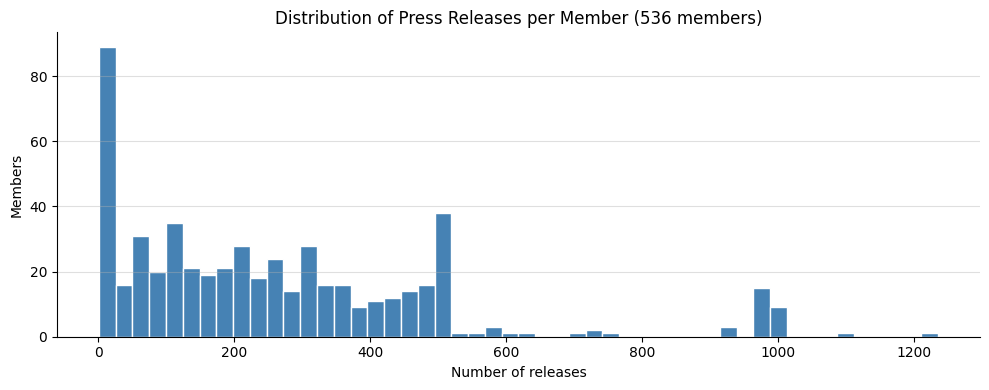

Median releases per member: 211
Mean releases per member:   263
Members with < 10 releases: 30


In [25]:
# Distribution of releases per member
dist = q('SELECT n_releases FROM press_members ORDER BY n_releases')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dist['n_releases'], bins=50, color='steelblue', edgecolor='white')
ax.set_title('Distribution of Press Releases per Member (536 members)')
ax.set_xlabel('Number of releases')
ax.set_ylabel('Members')
plt.tight_layout()
plt.show()

print(f"Median releases per member: {dist['n_releases'].median():.0f}")
print(f"Mean releases per member:   {dist['n_releases'].mean():.0f}")
print(f"Members with < 10 releases: {(dist['n_releases'] < 10).sum()}")

---
## 6. Cross-Source Bridges

Three bridges connect the four data sources into one corpus. Verifying each bridge confirms the database can answer cross-source questions.

In [26]:
print('=== Bridge 1: Senate ↔ House (via senate_registrant_id) ===')
bridge1 = q("""
SELECT
  count(*)                                                                     AS total_house_filings,
  sum(CASE WHEN senate_registrant_id IS NOT NULL THEN 1 ELSE 0 END)           AS matched_to_senate,
  count(DISTINCT senate_registrant_id)                                         AS distinct_registrants,
  (SELECT count(*) FROM senate_registrants)                                    AS total_senate_registrants
FROM house_filings
""")
t = bridge1['total_house_filings'][0]
m = bridge1['matched_to_senate'][0]
print(f"  House filings total:           {t:>8,}")
print(f"  Matched to senate registrant:  {m:>8,}  ({m/t*100:.2f}%)")
print(f"  Distinct registrants matched:  {bridge1['distinct_registrants'][0]:>8,}")
print(f"  Total Senate registrants:      {bridge1['total_senate_registrants'][0]:>8,}")
print(f"  Registrants in both chambers:  {bridge1['distinct_registrants'][0]:>8,} / {bridge1['total_senate_registrants'][0]:,}")
print()
print("  Verdict: 100.0% match — deterministic join, not fuzzy.")

=== Bridge 1: Senate ↔ House (via senate_registrant_id) ===
  House filings total:            409,650
  Matched to senate registrant:   409,650  (100.00%)
  Distinct registrants matched:     6,643
  Total Senate registrants:         6,823
  Registrants in both chambers:     6,643 / 6,823

  Verdict: 100.0% match — deterministic join, not fuzzy.


In [27]:
print('=== Bridge 2: Press ↔ Lobbying (via bioguide_id) ===')
bridge2 = q("""
SELECT
  count(*)                                                           AS total_releases,
  sum(CASE WHEN bioguide_id IS NOT NULL THEN 1 ELSE 0 END)          AS has_bioguide,
  count(DISTINCT bioguide_id)                                        AS distinct_bioguides
FROM press_releases
""")
t = bridge2['total_releases'][0]
h = bridge2['has_bioguide'][0]
print(f"  Press releases total:          {t:>8,}")
print(f"  With bioguide_id:              {h:>8,}  ({h/t*100:.2f}%)")
print(f"  Distinct member bioguides:     {bridge2['distinct_bioguides'][0]:>8,}")
print()
print("  Verdict: 99.9% coverage. 122 missing = committee/leadership posts with no member object.")

=== Bridge 2: Press ↔ Lobbying (via bioguide_id) ===
  Press releases total:           141,332
  With bioguide_id:               141,210  (99.91%)
  Distinct member bioguides:          536

  Verdict: 99.9% coverage. 122 missing = committee/leadership posts with no member object.


In [28]:
print('=== Bridge 3: Contribution Honorees ↔ Members (honoree_member_map) ===')
has_map = conn.execute(
    "SELECT count(*) FROM sqlite_master WHERE type='table' AND name='honoree_member_map'"
).fetchone()[0]

if has_map:
    bridge3 = q("""
    SELECT
      count(*)                                                               AS total_map_rows,
      sum(CASE WHEN bioguide IS NOT NULL THEN 1 ELSE 0 END)                 AS resolved_to_member,
      sum(CASE WHEN confidence >= 0.9 THEN 1 ELSE 0 END)                    AS high_confidence,
      count(DISTINCT honoree_name)                                           AS distinct_honoree_names,
      count(DISTINCT bioguide)                                               AS distinct_bioguides
    FROM honoree_member_map
    """)
    t = bridge3['total_map_rows'][0]
    r = bridge3['resolved_to_member'][0]
    print(f"  Total map rows:                {t:>8,}")
    print(f"  Resolved to a member:          {r:>8,}  ({r/t*100:.1f}%)")
    print(f"  High confidence (>= 0.9):      {bridge3['high_confidence'][0]:>8,}")
    print(f"  Distinct honoree names:        {bridge3['distinct_honoree_names'][0]:>8,}")
    print(f"  Distinct member bioguides:     {bridge3['distinct_bioguides'][0]:>8,}")
    print()
    print("  ~45% of distinct honorees are non-members (party PACs, NRSC/DSCC, etc.) — correct by design.")

    # Confidence method breakdown
    methods = q("""
    SELECT method, confidence,
           count(*) AS n_rows,
           sum(CASE WHEN bioguide IS NOT NULL THEN 1 ELSE 0 END) AS resolved
    FROM honoree_member_map
    GROUP BY method, confidence
    ORDER BY confidence DESC
    """)
    print()
    print('  Match method breakdown:')
    print(methods.to_string(index=False))
else:
    print("  honoree_member_map not found — run python scripts/ingest_members.py to build it.")

=== Bridge 3: Contribution Honorees ↔ Members (honoree_member_map) ===
  Total map rows:                  51,250
  Resolved to a member:            23,191  (45.3%)
  High confidence (>= 0.9):        16,790
  Distinct honoree names:          51,250
  Distinct member bioguides:          811

  ~45% of distinct honorees are non-members (party PACs, NRSC/DSCC, etc.) — correct by design.

  Match method breakdown:
     method  confidence  n_rows  resolved
  full_name         1.0   14962     14962
 first_last         0.9    1740      1740
  full_name         0.9      88        88
last_unique         0.6    6401      6401
        NaN         NaN   28059         0


---
## 7. Data-Quality Checks

Live queries re-deriving the key quality signals in this corpus. Numbers here are computed fresh each time the notebook runs — if a fact changed, this section will reflect it.

**For context on how the database was built** — including ingestion decisions that produced these numbers (deduplication logic, XML sanitization, honoree-name matching design) — see `docs/senate_db.md`, `docs/house_db.md`, `docs/press_db.md`, and `docs/members_db.md`.

In [29]:
junk_pos = q("""
SELECT covered_position, count(*) AS n
FROM senate_activity_lobbyists
WHERE covered_position IN ('N/A', 'See prior filing', 'Legislative Consultant', 'Partner')
GROUP BY covered_position ORDER BY n DESC
""")
total_pos = conn.execute(
    "SELECT count(*) FROM senate_activity_lobbyists WHERE covered_position IS NOT NULL"
).fetchone()[0]
junk_pos['% of non-null covered_position'] = (junk_pos['n'] / total_pos * 100).map('{:.1f}%'.format)
junk_pos['n'] = junk_pos['n'].map('{:,}'.format)
print("Senate covered_position — known junk placeholder values")
print("(excluded from the revolving-door count in section 2; see docs/senate_db.md for detail)")
display(junk_pos)

Senate covered_position — known junk placeholder values
(excluded from the revolving-door count in section 2; see docs/senate_db.md for detail)


,covered_position,n,% of non-null covered_position
0,See prior filing,"5,166",0.9%
1,N/A,"4,439",0.8%
2,Legislative Consultant,"3,866",0.7%
3,Partner,"1,593",0.3%


In [30]:
honoree_junk = q("""
SELECT
  honoree_name,
  count(*)        AS n_items,
  sum(amount_num) AS total_usd
FROM senate_contribution_items
WHERE honoree_name IN (
    'N/A', 'None', 'NRSC', 'DSCC', 'NRCC', 'DCCC',
    'Senate Majority PAC', 'SENATE MAJORITY PAC', 'House Majority PAC',
    'National Republican Senatorial Committee',
    'Democratic Senatorial Campaign Committee',
    'National Republican Congressional Committee',
    'Democratic Congressional Campaign Committee'
)
GROUP BY honoree_name
ORDER BY total_usd DESC
""")
honoree_junk['total_usd'] = honoree_junk['total_usd'].map('${:,.0f}'.format)
honoree_junk['n_items'] = honoree_junk['n_items'].map('{:,}'.format)
print("Senate contributions — non-member honorees included in section 3 totals")
print("(filter these out before any member-level contribution analysis; see docs/senate_db.md)")
display(honoree_junk)

Senate contributions — non-member honorees included in section 3 totals
(filter these out before any member-level contribution analysis; see docs/senate_db.md)


,honoree_name,n_items,total_usd
0,N/A,"5,475","$22,073,597"
1,NRSC,"2,111","$12,316,596"
2,DSCC,"1,695","$11,508,169"
3,Senate Majority PAC,44,"$9,897,923"
4,NRCC,"1,597","$9,892,357"
5,DCCC,"1,337","$9,709,714"
6,House Majority PAC,50,"$9,707,950"
7,None,"1,074","$9,375,283"
8,Democratic Senatorial Campaign Committee,"1,021","$8,717,010"
9,National Republican Senatorial Committee,"1,656","$8,580,279"


In [31]:
if conn.execute("SELECT count(*) FROM sqlite_master WHERE type='table' AND name='honoree_member_map'").fetchone()[0]:
    low_conf = conn.execute(
        "SELECT count(*) FROM honoree_member_map WHERE method='last_unique'"
    ).fetchone()[0]
    total_matched = conn.execute(
        "SELECT count(*) FROM honoree_member_map WHERE bioguide IS NOT NULL"
    ).fetchone()[0]
    print(f"honoree_member_map — last_unique matches (confidence 0.6): {low_conf:,} of {total_matched:,} matched rows ({pct(low_conf, total_matched)})")
    print("(treat as leads to verify, not publishable facts; see docs/members_db.md)")

honoree_member_map — last_unique matches (confidence 0.6): 6,401 of 23,191 matched rows (27.6%)
(treat as leads to verify, not publishable facts; see docs/members_db.md)


In [32]:
pr_nulls = q("""
SELECT
  count(*)                                                        AS total,
  sum(CASE WHEN bioguide_id IS NULL THEN 1 ELSE 0 END)           AS no_bioguide,
  sum(CASE WHEN date IS NULL THEN 1 ELSE 0 END)                  AS no_date,
  sum(CASE WHEN text IS NULL OR text = '' THEN 1 ELSE 0 END)     AS no_text
FROM press_releases
""")
t = pr_nulls['total'][0]
pr_check = pd.DataFrame([
    {'field': 'total releases',    'missing': 0,                          '% missing': '0.00%'},
    {'field': 'bioguide_id',       'missing': pr_nulls['no_bioguide'][0], '% missing': pct(pr_nulls['no_bioguide'][0], t, 2)},
    {'field': 'date',              'missing': pr_nulls['no_date'][0],     '% missing': pct(pr_nulls['no_date'][0], t, 2)},
    {'field': 'text (null/empty)', 'missing': pr_nulls['no_text'][0],     '% missing': pct(pr_nulls['no_text'][0], t, 2)},
])
pr_check['missing'] = pr_check['missing'].map('{:,}'.format)
print("Press releases — null/missing rates on key fields")
display(pr_check)

Press releases — null/missing rates on key fields


,field,missing,% missing
0,total releases,0,0.00%
1,bioguide_id,122,0.09%
2,date,14,0.01%
3,text (null/empty),81,0.06%


In [33]:
house_lob = q("""
SELECT
  count(*) AS total_lobbyist_rows,
  sum(CASE WHEN covered_position IS NOT NULL
       AND covered_position NOT IN ('N/A', 'See prior filing', 'Legislative Consultant', 'Partner')
       THEN 1 ELSE 0 END) AS real_covered_position_rows
FROM house_filing_lobbyists
""")
t_lob = house_lob['total_lobbyist_rows'][0]
print("House filing lobbyists — no stable ID; covered_position quality")
print("(house lobbyists are name-only and cannot be directly joined to senate_lobbyists; see docs/house_db.md)")
lob_df = pd.DataFrame([
    {'metric': 'total lobbyist rows',          'count': f"{t_lob:,}",                                         '% of total': '100.0%'},
    {'metric': 'real covered_position values', 'count': f"{house_lob['real_covered_position_rows'][0]:,}",    '% of total': pct(house_lob['real_covered_position_rows'][0], t_lob)},
])
display(lob_df)

House filing lobbyists — no stable ID; covered_position quality
(house lobbyists are name-only and cannot be directly joined to senate_lobbyists; see docs/house_db.md)


,metric,count,% of total
0,total lobbyist rows,"1,409,887",100.0%
1,real covered_position values,"329,712",23.4%


In [34]:
conn.close()
print('Database connection closed.')

Database connection closed.
